# AI-Powered Customer Review Intelligence System

## Project Overview

This project develops an AI-powered customer review intelligence system designed to analyse large volumes of customer feedback. The aim is to classify sentiment, identify recurring complaint themes, and generate meaningful business insights from textual reviews.

Customer reviews contain valuable information about satisfaction, dissatisfaction, service quality, and product issues. However, manually reading thousands of reviews is time-consuming and inefficient. This project applies Natural Language Processing (NLP), supervised machine learning, and unsupervised learning to automate this process.

The project includes:

- Data cleaning and preprocessing
- Sentiment label creation from customer ratings
- Exploratory data analysis
- Text cleaning and feature engineering using TF-IDF
- Sentiment classification using Logistic Regression
- Handling class imbalance
- Complaint theme discovery using KMeans clustering
- AI-based insight generation using large language model concepts

This system can help organisations understand customer behaviour more effectively and support better decision-making.

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.cluster import KMeans

## Data Loading

In this step, the dataset is loaded into Python using the pandas library.

Real-world review datasets often contain formatting inconsistencies, encoding issues, and broken rows. Therefore, suitable parameters are used while reading the file to improve robustness and ensure that the dataset loads successfully.

In [2]:
df = pd.read_csv(
    "Amazon_Reviews.csv",
    encoding="latin1",
    engine="python",
    on_bad_lines="skip"
)

print(df.head())
print(df.shape)
print(df.columns)

      Reviewer Name                     Profile Link Country Review Count  \
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review   
1  Daniel ohalloran  /users/5d75e460200c1f6a6373648c      GB    9 reviews   
2          p fisher  /users/546cfcf1000064000197b88f      GB   90 reviews   
3         Greg Dunn  /users/62c35cdbacc0ea0012ccaffa      AU    5 reviews   
4     Sheila Hannah  /users/5ddbe429478d88251550610e      GB    8 reviews   

                Review Date                  Rating  \
0  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars   
1  2024-09-16T18:26:46.000Z  Rated 1 out of 5 stars   
2  2024-09-16T21:47:39.000Z  Rated 1 out of 5 stars   
3  2024-09-17T07:15:49.000Z  Rated 1 out of 5 stars   
4  2024-09-16T18:37:17.000Z  Rated 1 out of 5 stars   

                                      Review Title  \
0       A Store That Doesn't Want to Sell Anything   
1         Had multiple orders one turned up andâ¦   
2                      I informed these repr

## Initial Data Inspection

Before applying any preprocessing or modelling steps, it is important to understand the structure of the dataset.

This includes:
- checking the dimensions of the dataset
- reviewing the available columns
- identifying missing values
- understanding the type and format of important variables such as ratings and review text

This step helps ensure that the data is suitable for analysis and highlights any issues that need to be addressed.

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSample values from Rating column:")
print(df["Rating"].dropna().head(10))

Shape of dataset: (21214, 9)

Columns:
Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')

Missing values:
Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

Sample values from Rating column:
0    Rated 1 out of 5 stars
1    Rated 1 out of 5 stars
2    Rated 1 out of 5 stars
3    Rated 1 out of 5 stars
4    Rated 1 out of 5 stars
5    Rated 1 out of 5 stars
6    Rated 1 out of 5 stars
7    Rated 5 out of 5 stars
8    Rated 1 out of 5 stars
9    Rated 5 out of 5 stars
Name: Rating, dtype: object


## Selecting Relevant Columns

Not all columns are required for sentiment analysis and customer insight generation.

The most relevant columns for this project are:
- Country
- Review Date
- Rating
- Review Title
- Review Text

These columns provide both the textual content and contextual information needed for analysis.

In [4]:
df = df[["Country", "Review Date", "Rating", "Review Title", "Review Text"]].copy()

print(df.head())
print(df.shape)

  Country               Review Date                  Rating  \
0      US  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars   
1      GB  2024-09-16T18:26:46.000Z  Rated 1 out of 5 stars   
2      GB  2024-09-16T21:47:39.000Z  Rated 1 out of 5 stars   
3      AU  2024-09-17T07:15:49.000Z  Rated 1 out of 5 stars   
4      GB  2024-09-16T18:37:17.000Z  Rated 1 out of 5 stars   

                                      Review Title  \
0       A Store That Doesn't Want to Sell Anything   
1         Had multiple orders one turned up andâ¦   
2                      I informed these reprobates   
3  Advertise one price then increase it on website   
4             If I could give a lower rate I would   

                                         Review Text  
0  I registered on the website, tried to order a ...  
1  Had multiple orders one turned up and driver h...  
2  I informed these reprobates that I WOULD NOT B...  
3  I have bought from Amazon before and no proble...  
4  If I could give a 

## Rating Extraction and Transformation

The rating column is stored as text, for example:

- "Rated 1 out of 5 stars"

To use ratings in analysis and modelling, the numeric value must be extracted and converted into a numerical format.

This transformation enables the creation of sentiment labels and supports further quantitative analysis.

In [5]:
df["rating_num"] = df["Rating"].astype(str).str.extract(r"(\d)", expand=False)
df["rating_num"] = pd.to_numeric(df["rating_num"], errors="coerce")

print("Missing extracted ratings:", df["rating_num"].isna().sum())

df = df.dropna(subset=["rating_num"]).copy()
df["rating_num"] = df["rating_num"].astype(int)

print(df[["Rating", "rating_num"]].head())
print(df["rating_num"].value_counts().sort_index())

Missing extracted ratings: 159
                   Rating  rating_num
0  Rated 1 out of 5 stars           1
1  Rated 1 out of 5 stars           1
2  Rated 1 out of 5 stars           1
3  Rated 1 out of 5 stars           1
4  Rated 1 out of 5 stars           1
rating_num
1    13123
2     1227
3      885
4     1292
5     4528
Name: count, dtype: int64


## Sentiment Label Creation

To transform the problem into a classification task, sentiment labels are created from the numeric rating values.

The following mapping is used:

- Ratings 1–2 → Negative
- Rating 3 → Neutral
- Ratings 4–5 → Positive

This approach converts raw ratings into interpretable categories that reflect customer satisfaction.

In [6]:
def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["rating_num"].apply(get_sentiment)

print(df["sentiment"].value_counts())

sentiment
Negative    14350
Positive     5820
Neutral       885
Name: count, dtype: int64


## Combining Review Title and Review Text

To improve the richness of the textual data, the review title and review text are combined into a single text field.

This provides more context to the model, as titles often contain concise emotional summaries while review text contains detailed explanations.

In [7]:
df["Review Title"] = df["Review Title"].fillna("")
df["Review Text"] = df["Review Text"].fillna("")

df["full_review"] = (df["Review Title"] + " " + df["Review Text"]).str.strip()

print(df[["Review Title", "Review Text", "full_review"]].head())

                                      Review Title  \
0       A Store That Doesn't Want to Sell Anything   
1         Had multiple orders one turned up andâ¦   
2                      I informed these reprobates   
3  Advertise one price then increase it on website   
4             If I could give a lower rate I would   

                                         Review Text  \
0  I registered on the website, tried to order a ...   
1  Had multiple orders one turned up and driver h...   
2  I informed these reprobates that I WOULD NOT B...   
3  I have bought from Amazon before and no proble...   
4  If I could give a lower rate I would! I cancel...   

                                         full_review  
0  A Store That Doesn't Want to Sell Anything I r...  
1  Had multiple orders one turned up andâ¦ Had m...  
2  I informed these reprobates I informed these r...  
3  Advertise one price then increase it on websit...  
4  If I could give a lower rate I would If I coul...  


## Text Cleaning and NLP Preprocessing

Customer reviews are unstructured and noisy. Before they can be used in machine learning, the text must be cleaned and standardised.

The preprocessing steps include:
- converting text to lowercase
- removing URLs
- removing numbers
- removing punctuation
- removing extra whitespace

This improves consistency and helps the model focus on meaningful words.

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["full_review"].apply(clean_text)

print(df[["full_review", "clean_text"]].head())

                                         full_review  \
0  A Store That Doesn't Want to Sell Anything I r...   
1  Had multiple orders one turned up andâ¦ Had m...   
2  I informed these reprobates I informed these r...   
3  Advertise one price then increase it on websit...   
4  If I could give a lower rate I would If I coul...   

                                          clean_text  
0  a store that doesnt want to sell anything i re...  
1  had multiple orders one turned up andâ¦ had m...  
2  i informed these reprobates i informed these r...  
3  advertise one price then increase it on websit...  
4  if i could give a lower rate i would if i coul...  


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the distribution and characteristics of the dataset before modelling.

This section examines:
- rating distribution
- sentiment distribution
- country distribution
- review length patterns

These insights help identify important trends and support better interpretation of modelling results.

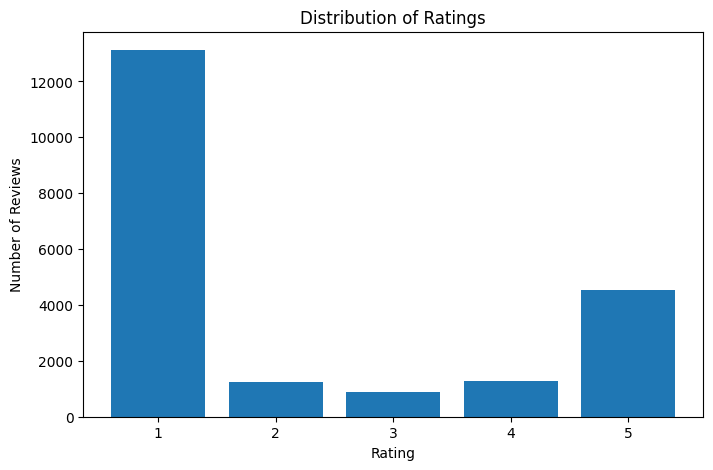

In [9]:
rating_counts = df["rating_num"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

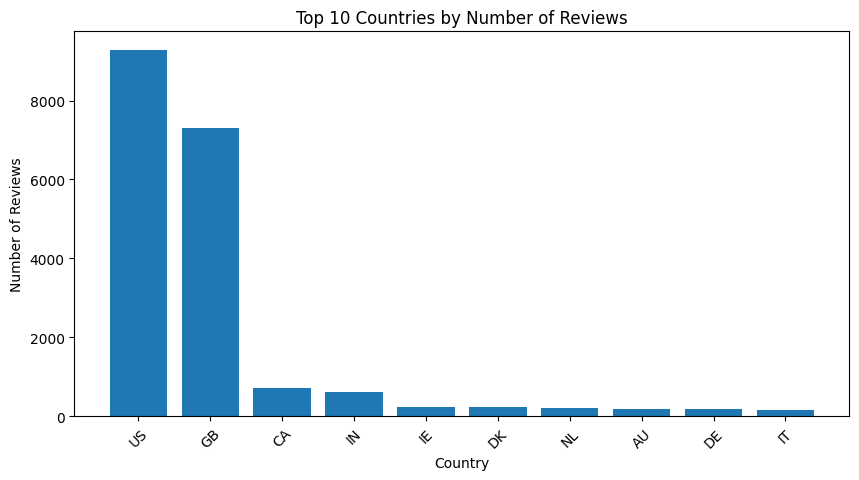

In [10]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_countries.index, top_countries.values)
plt.title("Top 10 Countries by Number of Reviews")
plt.xlabel("Country")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

## Review Length Analysis

Review length can provide additional context about customer behaviour. Longer reviews may contain more detailed complaints or experiences, while shorter reviews may express quick satisfaction or frustration.

Analysing review length helps us better understand the nature of the text data.

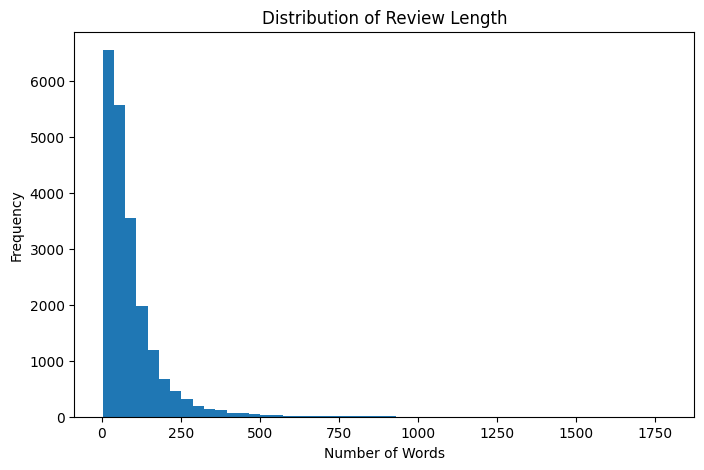

count    21055.000000
mean        87.879554
std         93.315619
min          2.000000
25%         31.000000
50%         62.000000
75%        111.000000
max       1786.000000
Name: review_length, dtype: float64


In [11]:
df["review_length"] = df["clean_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
plt.hist(df["review_length"], bins=50)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

print(df["review_length"].describe())

## Train-Test Split

The cleaned review text is used as the input feature, while the sentiment label is used as the target variable.

The dataset is split into:
- training data, used to train the model
- testing data, used to evaluate model performance on unseen data

This is a standard practice in supervised machine learning to assess generalisation performance.

## Feature Engineering using TF-IDF

Machine learning models cannot interpret raw text directly. Therefore, textual data must be converted into numerical features.

TF-IDF (Term Frequency–Inverse Document Frequency) is used to represent text numerically by measuring how important each word is in a document relative to the whole dataset.

This creates a sparse numerical matrix suitable for text classification.

In [12]:
X = df["clean_text"]
y = df["sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (16844, 5000)
Testing shape: (4211, 5000)


## Baseline Sentiment Classification Model

A Logistic Regression model is used as the baseline classifier for sentiment prediction.

This model is well-suited for text classification tasks and provides a strong, interpretable starting point for performance evaluation.

In [13]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.9164094039420565
              precision    recall  f1-score   support

    Negative       0.92      0.98      0.95      2870
     Neutral       0.58      0.04      0.07       177
    Positive       0.91      0.89      0.90      1164

    accuracy                           0.92      4211
   macro avg       0.80      0.64      0.64      4211
weighted avg       0.90      0.92      0.90      4211



## Handling Class Imbalance

The dataset contains a much larger number of negative reviews compared with neutral reviews. This creates a class imbalance problem.

When class imbalance is present, a model may achieve high overall accuracy while performing poorly on minority classes. To address this issue, class weighting is applied so that underrepresented classes receive more importance during training.

This improves fairness and produces a more balanced model.

In [14]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Improved Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Improved Accuracy: 0.8636903348373308
              precision    recall  f1-score   support

    Negative       0.95      0.89      0.92      2870
     Neutral       0.18      0.42      0.26       177
    Positive       0.90      0.86      0.88      1164

    accuracy                           0.86      4211
   macro avg       0.68      0.72      0.69      4211
weighted avg       0.91      0.86      0.88      4211



## Model Evaluation

The model is evaluated using several performance metrics:

- Accuracy: overall proportion of correct predictions
- Precision: how many predicted instances of a class are correct
- Recall: how many actual instances of a class are correctly identified
- F1-score: the balance between precision and recall

These metrics provide a more complete understanding of performance than accuracy alone, especially in imbalanced datasets.

## Confusion Matrix

The confusion matrix shows how the model’s predictions compare with the true sentiment labels.

This helps identify:
- which classes are predicted well
- where misclassifications occur
- whether the model struggles with certain categories such as neutral sentiment

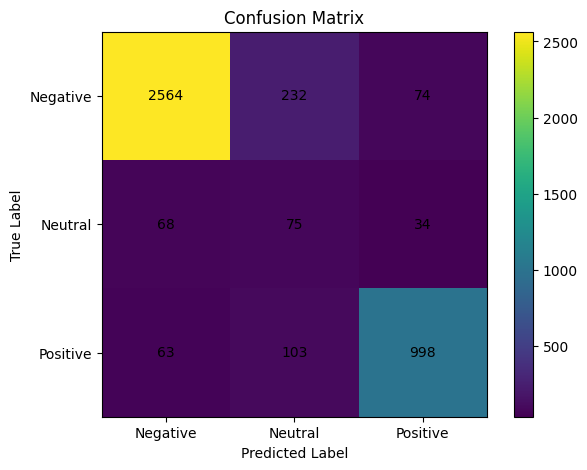

In [15]:
cm = confusion_matrix(y_test, y_pred, labels=["Negative", "Neutral", "Positive"])

plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = ["Negative", "Neutral", "Positive"]
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Interpretation of Classification Results

The baseline model achieved strong overall accuracy, but performance on the neutral class was weak due to class imbalance.

After applying class weighting, the model became more balanced and better able to recognise underrepresented classes. Although overall accuracy decreased slightly, the improved model provides a fairer and more realistic representation of customer sentiment.

This highlights the importance of evaluating machine learning models beyond accuracy alone.

## Unsupervised Learning: Complaint Theme Discovery

In addition to sentiment classification, unsupervised learning is used to identify recurring themes in negative reviews.

Negative reviews are especially valuable because they highlight customer dissatisfaction and common pain points. KMeans clustering is applied to group similar negative reviews together based on their textual content.

This helps uncover hidden patterns without requiring manual labels.

In [16]:
negative_reviews = df[df["sentiment"] == "Negative"].copy()

print("Number of negative reviews:", negative_reviews.shape[0])

Number of negative reviews: 14350


In [17]:
neg_vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
X_neg = neg_vectorizer.fit_transform(negative_reviews["clean_text"])

print(X_neg.shape)

(14350, 2000)


In [18]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
negative_reviews["cluster"] = kmeans.fit_predict(X_neg)

print(negative_reviews[["clean_text", "cluster"]].head())

                                          clean_text  cluster
0  a store that doesnt want to sell anything i re...        3
1  had multiple orders one turned up andâ¦ had m...        1
2  i informed these reprobates i informed these r...        3
3  advertise one price then increase it on websit...        4
4  if i could give a lower rate i would if i coul...        0


## Interpreting Clusters

To understand the meaning of each cluster, the most important words from each cluster centre are examined.

These top words help identify the main complaint themes present in negative customer reviews.

In [19]:
terms = neg_vectorizer.get_feature_names_out()

for i in range(5):
    print(f"\nCluster {i}")
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[-10:][::-1]
    top_words = [terms[j] for j in top_indices]
    print(top_words)


Cluster 0
['account', 'card', 'amazon', 'gift', 'credit', 'money', 'bank', 'customer', 'email', 'service']

Cluster 1
['delivery', 'amazon', 'day', 'delivered', 'prime', 'package', 'driver', 'order', 'time', 'service']

Cluster 2
['text', 'review', 'service', 'worst', 'bad', 'customer', 'terrible', 'company', 'amazon', 'good']

Cluster 3
['amazon', 'item', 'refund', 'order', 'company', 'money', 'prime', 'ordered', 'product', 'items']

Cluster 4
['service', 'customer', 'amazon', 'worst', 'terrible', 'horrible', 'bad', 'company', 'refund', 'time']


In [20]:
for i in range(5):
    print(f"\n{'='*60}")
    print(f"Cluster {i} Sample Reviews")
    print(f"{'='*60}")
    
    sample_texts = negative_reviews[negative_reviews["cluster"] == i]["Review Text"].head(3)
    for j, review in enumerate(sample_texts, start=1):
        print(f"\nReview {j}:")
        print(review[:500])


Cluster 0 Sample Reviews

Review 1:
If I could give a lower rate I would! I cancelled my Amazon Prime in February and subsequently found that they had continued to charge me. When I contacted them they refused to give details of who had set up the payment as I didn't have Prime membership at that time. My credit card company cancelled the payment for me and refunded the payments made in June. I have just discovered that Amazon Prime has set up payments again without me being a Prime member!! I have had to cancel my credit card to 

Review 2:
My bank card froze only with amazon so couldn't order anything.Package said delivered at the post office when it hasn't been.Spoke to customer services about my card and he was very short with me and patronising when he was telling me how to take my bank card off then re add it. 

Review 3:
I put onw star because I can't leave a zero ...I ordered an item for Â£59.99.. it arrived on  time but wasnt suitable so I sent it back , it was refunded to my

##  Cluster Interpretation with Real Review Evidence

To validate the clustering results, sample reviews from each cluster were analysed. This confirms that the clusters represent meaningful and distinct categories of customer complaints.

---

### Cluster 0: Payment, Billing and Refund Issues

This cluster is strongly associated with financial and account-related problems.

**Evidence from reviews:**
- Customers report unauthorised or repeated charges (e.g. Amazon Prime charges continuing after cancellation)
- Issues with refunds being delayed or returned to incorrect accounts (e.g. gift cards instead of original payment method)
- Problems with bank cards being declined or restricted

**Interpretation:**
These reviews highlight serious issues in payment processing and account management.

**Business Impact:**
Financial issues are highly sensitive and directly impact customer trust. Failure in this area can lead to customer churn and reputational damage.

---

### Cluster 1: Delivery, Logistics and Service Failures

This cluster captures issues related to delivery and operational service.

**Evidence from reviews:**
- Packages marked as delivered but not received
- Delayed or failed deliveries
- Poor communication from drivers
- Inappropriate or unprofessional behaviour from delivery staff
- Complaints about customer service quality during delivery issues

**Interpretation:**
Delivery reliability and last-mile logistics are major sources of dissatisfaction.

**Business Impact:**
Delivery performance is critical in e-commerce. Repeated failures significantly reduce customer satisfaction and loyalty.

---

### Key Insight

The combination of clustering and real review analysis shows that customer dissatisfaction is primarily driven by:

- Payment and refund issues  
- Delivery and logistics failures  
- Poor customer service interactions  

This demonstrates that unsupervised learning can effectively uncover root causes of negative customer experiences without requiring manual labelling.

## AI-Based Insight Generation

A large language model can be integrated into this system to summarise large groups of customer reviews and generate actionable insights.

For example, an LLM connected through a framework such as LangChain could:
- summarise key complaint themes
- identify the most urgent customer pain points
- suggest practical business improvements

This extends the system beyond prediction and turns it into a decision-support tool.

In [21]:
cluster_0_reviews = negative_reviews[negative_reviews["cluster"] == 0]["Review Text"].dropna().head(20)
cluster_0_text = " ".join(cluster_0_reviews.astype(str))

print(cluster_0_text[:2000])

If I could give a lower rate I would! I cancelled my Amazon Prime in February and subsequently found that they had continued to charge me. When I contacted them they refused to give details of who had set up the payment as I didn't have Prime membership at that time. My credit card company cancelled the payment for me and refunded the payments made in June. I have just discovered that Amazon Prime has set up payments again without me being a Prime member!! I have had to cancel my credit card to stop them!!Do not trust Amazon Prime.  My bank card froze only with amazon so couldn't order anything.Package said delivered at the post office when it hasn't been.Spoke to customer services about my card and he was very short with me and patronising when he was telling me how to take my bank card off then re add it.  I put onw star because I can't leave a zero ...I ordered an item for Â£59.99.. it arrived on  time but wasnt suitable so I sent it back , it was refunded to my gift card account , 

##  Business Impact and Recommendations

The findings from this analysis suggest several key areas for improvement:

### 1. Payment and Billing Systems
- Improve transparency in subscription charges
- Ensure refunds are processed correctly and promptly
- Prevent unauthorised or repeated transactions

### 2. Delivery and Logistics
- Improve delivery tracking accuracy
- Strengthen driver accountability and behaviour standards
- Reduce failed or delayed deliveries

### 3. Customer Service Quality
- Provide better training for customer support staff
- Improve response time and communication quality
- Ensure professional handling of customer complaints

Addressing these issues can significantly improve customer satisfaction and reduce negative feedback.

### Example LLM Prompt

A prompt for a large language model could be:

"Summarise the main customer complaints from the following reviews. Identify the top three issues and suggest actions the business could take to improve customer satisfaction."

This shows how modern AI can support business decision-making by reducing the need for manual review.

## Risks and Ethical Considerations

Several risks and ethical considerations are relevant to this project.

### Technical Risks
- class imbalance may affect model fairness
- noisy or inconsistent text can reduce model quality
- clusters may not always represent perfectly distinct themes
- LLM-generated summaries may be vague or inconsistent

### Ethical Considerations
- customer reviews may contain biased or extreme opinions
- any personally identifiable information should be removed
- model outputs should support, not replace, human judgement
- automated systems should be used responsibly and transparently

Addressing these issues is essential to ensure that the system is both effective and ethically appropriate.

## Realism and Feasibility

This project is realistic and achievable within a reasonable timeframe because:

- the dataset is publicly available and already loaded successfully
- sentiment labels can be created directly from ratings
- TF-IDF and Logistic Regression provide a strong baseline
- clustering can be applied to a subset of negative reviews
- LLM integration can be demonstrated conceptually or through a lightweight prototype

These factors make the project suitable for an academic bootcamp setting while still reflecting real-world business applications.

LangChain can be used to connect the review data with a large language model, enabling automated summarisation of customer feedback and generation of actionable insights. This extends the system beyond prediction into intelligent decision support.

##  Resources Required

This project requires the following resources:

### Data
- Customer review dataset (Amazon / Trustpilot-style dataset)

### Tools and Technologies
- Python
- pandas, numpy
- scikit-learn
- matplotlib
- TF-IDF for feature extraction
- KMeans clustering
- LangChain / LLM (conceptual integration)

### Learning Resources
- scikit-learn documentation
- NLP tutorials
- LangChain documentation
- Kaggle datasets and examples

##  Risks and Challenges

### Technical Risks
- Class imbalance affecting model performance
- Noisy and unstructured text data
- Clusters may not perfectly represent real categories
- LLM outputs may be inconsistent or inaccurate

### Mitigation Strategies
- Use class weighting to handle imbalance
- Apply text cleaning and preprocessing
- Validate clusters using real review samples
- Use careful prompt design for LLM outputs

##  Feasibility and Timeline

This project is realistic and achievable because:

- The dataset is publicly available and manageable
- Sentiment labels are derived directly from ratings
- A simple baseline model (Logistic Regression) is sufficient
- Clustering is applied only to a subset (negative reviews)
- LLM integration can be implemented as a lightweight prototype

### Proposed Timeline
- Week 1: Data cleaning and preprocessing
- Week 2: Sentiment model development
- Week 3: Model evaluation and improvement
- Week 4: Clustering and insight generation
- Week 5: LLM integration and final reporting

##  Ethical Considerations

### Bias
Customer reviews may contain subjective or biased opinions, which can influence model predictions.

### Privacy
Any personal identifiable information (PII) should be removed to protect user privacy.

### Transparency
Model predictions should be interpretable and used to support, not replace, human decision-making.

### Responsible Use
The system should be used to improve customer experience rather than manipulate or mislead customers.

## Conclusion

This project demonstrates how AI can be used to analyse customer feedback at scale. By combining natural language processing, supervised machine learning, and unsupervised learning, the system is able to classify sentiment, identify recurring complaint themes, and generate valuable business insights.

The classification model achieved strong performance overall, and class weighting improved fairness by addressing imbalance in the dataset. In addition, KMeans clustering revealed hidden patterns within negative reviews, highlighting common customer concerns.

The project also shows how large language model concepts could be integrated to automate insight generation and support decision-making. Overall, this system represents a practical and impactful application of AI in customer feedback analysis.

In [22]:
df.to_csv("cleaned_customer_reviews.csv", index=False)
negative_reviews.to_csv("negative_reviews_with_clusters.csv", index=False)

print("Files saved successfully.")

Files saved successfully.
